<a href="https://colab.research.google.com/github/doanhieung/colab_notebooks/blob/main/insightface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q datasets insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 62.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.4 MB/s eta 0:00:00


In [2]:
import datasets
import tarfile
import cv2
import os
import numpy as np
import insightface
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from multiprocessing import cpu_count
from joblib import Parallel, delayed
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image
from glob import glob
from tqdm.notebook import tqdm
from google.colab import drive
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
app = FaceAnalysis(providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 60778.32KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'device_id': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'device_id': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'cudnn_con

In [4]:
dataset = datasets.load_dataset("sammyboi1801/lfw-face-transformer-dataset")

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/3846 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/271 [00:00<?, ? examples/s]

In [5]:
%mkdir /content/data
%mkdir /content/data/train/
%mkdir /content/data/test/

In [7]:
data_path = '/content/data/'

i = 0
embeddings, labels = [], []
for data in tqdm(dataset['train']):
  image, label = data['image'], data['label']
  if not os.path.exists(lpath:= data_path + f'train/{label}/'):
    os.mkdir(lpath)
  image.save(ipath := lpath + f'/{i}.jpg')
  faces = app.get(ins_get_image(ipath.removesuffix('.jpg')))
  if len(faces) == 1:
    embedding = faces[0]['embedding']
    embeddings.append(embedding)
    labels.append(label)
  i+= 1
  # if i == 100:
  #   break
train_data = pd.DataFrame({
    'embedding': embeddings,
    'label': labels
})

i = 0
embeddings, labels = [], []
for data in tqdm(dataset['test']):
  image, label = data['image'], data['label']
  if not os.path.exists(lpath:= data_path + f'test/{label}/'):
    os.mkdir(lpath)
  image.save(ipath := lpath + f'/{i}.jpg')
  faces = app.get(ins_get_image(ipath.removesuffix('.jpg')))
  if len(faces) == 1:
    embedding = faces[0]['embedding']
    embeddings.append(embedding)
    labels.append(label)
  i+= 1
  # if i == 10:
  #   break
test_data = pd.DataFrame({
    'embedding': embeddings,
    'label': labels
})

  0%|          | 0/3846 [00:00<?, ?it/s]

  0%|          | 0/271 [00:00<?, ?it/s]

In [8]:
print(len(train_data), len(test_data))

3187 220


In [9]:
def cosine_similarity(x, y):
  return np.dot(x, y)/(np.linalg.norm(x)*np.linalg.norm(y))

In [10]:
intra_sim, inter_sim = [], []
i = 0
for row1 in tqdm(train_data.itertuples(), total=len(train_data)):
  for row2 in train_data.itertuples():
    if row1.Index != row2.Index:
      emb1, label1 = row1.embedding, row1.label
      emb2, label2 = row2.embedding, row2.label
      sim = cosine_similarity(emb1, emb2)
      if label1 == label2:
        intra_sim.append(sim)
      else:
        inter_sim.append(sim)

  0%|          | 0/3187 [00:00<?, ?it/s]

<Axes: xlabel='cosine_similarity', ylabel='Density'>

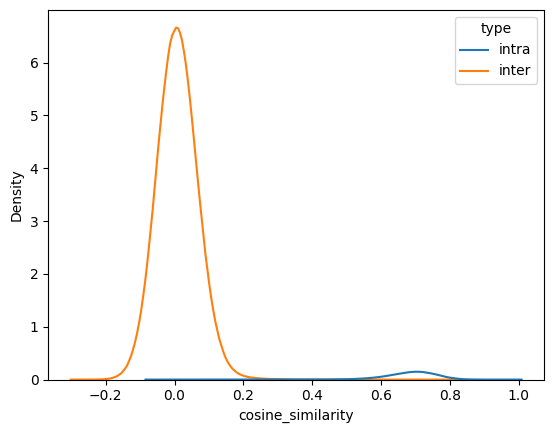

In [11]:
hist = pd.DataFrame({
        'cosine_similarity': intra_sim + inter_sim,
        'type': ['intra']*len(intra_sim) + ['inter']*len(inter_sim)
    })
sns.kdeplot(data=hist, x='cosine_similarity', hue='type')

In [12]:
threshold = 0.3

In [13]:
train_data.head()

,embedding,label
0,"[-0.73300177, -0.6526968, 0.94902074, 1.153567...",0
1,"[-2.177996, -1.2413534, 1.2289071, -2.000772, ...",0
2,"[-1.9024714, -1.7929626, 1.507094, -0.90933347...",0
3,"[-1.1144617, -0.99053335, 0.10087215, -0.37729...",0
4,"[0.27172434, -0.6017821, 0.5693019, 0.4005415,...",0


In [14]:
X = train_data.loc[:, 'embedding'].values
X = [x.tolist() for x in X.tolist()]
nn = NearestNeighbors(n_neighbors=1, algorithm='brute', metric='cosine').fit(X)

In [15]:
y = test_data['label'].values
y_hat = []

In [16]:
for row in tqdm(test_data.itertuples(), total=len(test_data)):
  embedding = row.embedding
  distances, indices = nn.kneighbors([embedding])
  predicted = train_data.loc[indices[0], 'label'].values[0]
  y_hat.append(predicted) if 1 - distances[0] >= threshold else y_hat.append(-1)

  0%|          | 0/220 [00:00<?, ?it/s]

In [17]:
accuracy_score(y, y_hat)

1.0